## Maybe some code for better understanding Bayes Theorem?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Perceptron
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, accuracy_score

In [2]:
rng = np.random.default_rng(42)

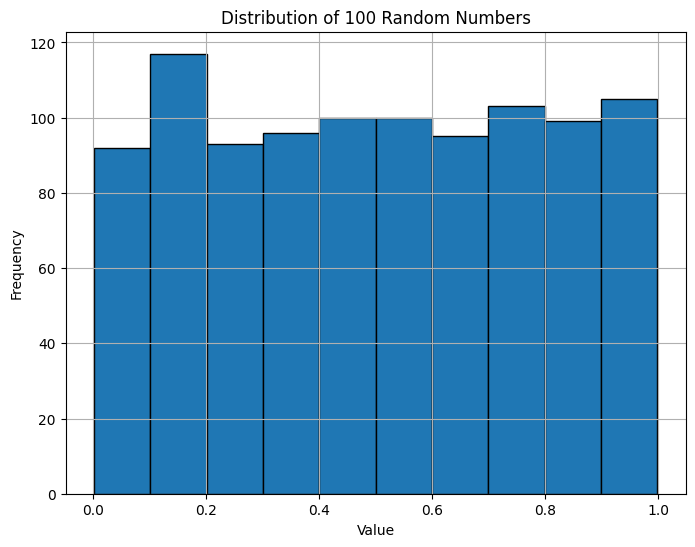

In [4]:
random_numbers = rng.random(1000) # uniform distribution

plt.figure(figsize=(8, 6))
plt.hist(random_numbers, bins=10, edgecolor='black')
plt.title('Distribution of 100 Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Task 1 — Polynomial regression (underfitting vs. overfitting)
Build the data with NumPy: X = np.sort(rng.uniform(0, 2*np.pi, 15)), y = np.sin(X) + rng.normal(0, 0.2, X.shape). Fit LinearRegression on PolynomialFeatures of degree 2, 3, 5, and 9. Plot each fit against np.sin. Identify which degree underfits and which overfits.


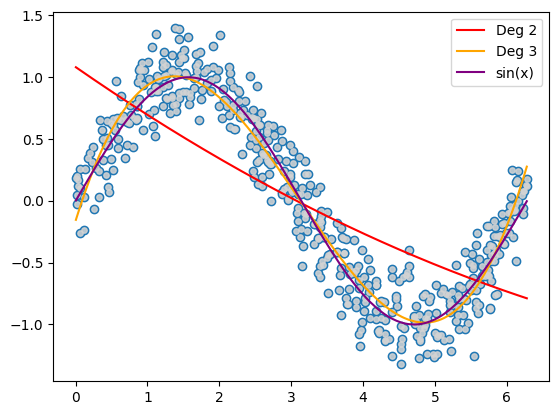

In [22]:
x = np.sort(rng.uniform(0, 2*np.pi, 500))
y = np.sin(x) + rng.normal(0, 0.2, x.shape)
plt.figure()
plt.scatter(x, y)

n_2 = PolynomialFeatures(degree=2)
n_3 = PolynomialFeatures(degree=3)



plt.scatter(x, y, color='lightgray',alpha=0.85, s=15)


# 2. Reshape x for scikit-learn
X = x.reshape(-1, 1)
model = LinearRegression()



X_2 = n_2.fit_transform(X)
model.fit(X_2, y)
plt.plot(x, model.predict(X_2), label='Deg 2', color='red')
X_3 = n_3.fit_transform(X)
model.fit(X_3, y)
plt.plot(x, model.predict(X_3), label='Deg 3', color='orange')

plt.plot(x, np.sin(x), label='sin(x)', color='purple')
plt.legend()

plt.show()

## Task 2 — Regularization
Reuse the degree-9 design matrix from Task 1. Refit with Ridge for increasing alpha. Plot how the regularization term tames the overfitted curve.


## Task 3 — Boosted decision tree regression
Generate X = np.sort(rng.uniform(0, 6, 100)).reshape(-1, 1), y = np.sin(X).ravel() + rng.normal(0, 0.3, 100). Fit one DecisionTreeRegressor and one AdaBoostRegressor (300 trees). Plot both and compare error.


In [ ]:
X = np.sort(rng.uniform(0, 6, 100)).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(0, 0.3, 100)

## Task 4 — Train/validation/test split and cross-validation
From the Task 3 data, make a NumPy index permutation (idx = rng.permutation(len(X))) and slice train/test manually. Then run KFold (k=4) with cross_val_score and compare the averaged CV score to the single hold-out score.


## Task 5 — Perceptron and the XOR problem
Linearly separable set: two Gaussian clusters via rng.normal, e.g. centers at [-2,-2] and [2,2]. Train Perceptron, report accuracy. Then the XOR set: X = np.array([[0,0],[0,1],[1,0],[1,1]]), y = np.array([0,1,1,0]). Show it cannot classify XOR correctly.


## Task 6 — One-hot encoding
Create labels with NumPy: labels = rng.choice(["house","car","cat","flower"], size=5).reshape(-1,1). Transform with OneHotEncoder and display the vectors.


## Task 7 — Least squares classification and outlier sensitivity
Two NumPy Gaussian clusters (labels 0/1). One-hot encode the labels and fit LinearRegression to obtain a decision boundary. Append a few far outliers with np.vstack, refit, and show the boundary shifts.


## Task 8 — Support Vector Machine
Same clusters as Task 7, with and without the outliers. Fit SVC(kernel="linear"). Plot the boundary, margins, and support vectors. Confirm the boundary is unaffected by outliers, unlike Task 7.